# Library Installation

In [1]:
pip install pandas numpy matplotlib seaborn tqdm scikit-learn datasets
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.3 MB/s eta 0:00:00


In [2]:
# 📌 File and Directory Management
import os
import tarfile

# 📌 Data Manipulation
import pandas as pd
import numpy as np

# 📌 Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 📌 Text Processing (NLP)
import re
import emoji
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from collections import Counter
import itertools

# 📌 Machine Learning and Utilities
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# 📌 Pandas Display Settings
pd.set_option("display.max_colwidth", None)  # Show entire text columns


# Open zipped file

In [3]:
# File path for the tar archive
tar_path = "aclImdb_v1.tar"

# Extracting the files
with tarfile.open(tar_path, "r") as tar:
    tar.extractall()  # Extracts to the current directory

print("File extracted successfully!")


Arquivo extraído com sucesso!


In [4]:
dataset_path = "aclImdb"

# Check the directory structure
for split in ["train", "test"]:
    for sentiment in ["pos", "neg"]:
        path = os.path.join(dataset_path, split, sentiment)
        print(f"{path}: {len(os.listdir(path))} files")


aclImdb/train/pos: 12500 arquivos
aclImdb/train/neg: 12500 arquivos
aclImdb/test/pos: 12500 arquivos
aclImdb/test/neg: 12500 arquivos


# Data loading

In [5]:
def load_imdb_data(directory):
    data = []
    labels = []

    for split in ["train", "test"]:
        for sentiment, label in [("pos", 1), ("neg", 0)]:
            path = os.path.join(directory, split, sentiment)

            for filename in tqdm(os.listdir(path), desc=f"Loading {split}/{sentiment}"):
                with open(os.path.join(path, filename), "r", encoding="utf-8") as file:
                    data.append(file.read())
                    labels.append(label)

    return pd.DataFrame({"review": data, "sentiment": labels})

# Load the data
df = load_imdb_data(dataset_path)

# Check a sample of the data
df.head()


Carregando test/neg: 100%|██████████| 12500/12500 [00:00<00:00, 35980.15it/s]


,review,sentiment
0,"When I first read the plot of this drama i assumed it was going to be like Sex and the City, however this drama is nothing like it. The stories the characters seem more real and you empathise with the situations more. The concept of the drama is similar, four 30 something women guide us through there friendships and relationships with problems and strife along the way. Katie the GP is a dark and brooding character who you find difficult to relate too and is best friends with Trudi a widow. Trudi's character is heart warming as you can relate to difficulties she is having along with the fact she is the only mother of the four. Jessica is the party girl very single minded and knows what she wants and how to get it. She is a likable character and is closest to Siobhan the newly wed who whilst loving her husband completely can't help her eyes wandering to her work colleague. Over all the drama is surprisingly addictive and if the BBC continue to produce the series it could do well. It is unlike other female cast dramas such as Sex and the city, or Desperate Housewives. This if played right could be the next Cold feet. Plus the male cast are not bad on the eyes too.",1
1,"This movie has been made by one of the most absurd humorists in Canada, Yves P. Pelletier. I was shocked for a second that he made a ROMANTIC comedy, but knowing he was a heavy cinephile, was seen in every local festival and in the local cinematheque, I had a positive feeling about this movie.<br /><br />Hell, I was right. Right off the bat, the scenario (written by Pelletier himself) is a bit twisted and hard to follow, but, in Pelletier's fashion it's a one-of-a-kind 90 minutes jack-in-the-box.<br /><br />Loosely inspired and mostly transformed allusion to Dangerous Liaisons (by Laclos) ""Les Aimants"" consists of a twisted game of writing notes on the fridge. Throughout the movie you'll get the occasion to find out who's who and who's writing to who on that goddam fridge....which pops up in an interesting love affair.<br /><br />Great storyline, great photography, great quotations of other movies. Should we ask more for a first movie?",1
2,"First ever viewing: July 21, 2008<br /><br />Very impressive screenplay and comedic acting and timing in this film. Now 40 years old, it has lost none of it's power. Neil Simon displays excellent insight into human nature and relationships as well as how to create genuine comedy from unusual situations. Jack Lemmon and Walter Matthau give great comedic performances. Neil Simon was inspired by actual events in his own life to write the play this film is based on.<br /><br />One of the best written and acted Hollywood comedies of all time!<br /><br />Surprisingly, only nominated for 2 Academy Awards: ""Best Adapted Screenplay"" and ""Best Film Editing"". Hollywood rarely awards comedies, no matter how well they are made.",1
3,myself and 2 sisters watched all 3 series of Tenko and agree this is by far one of the BBC better series.The whole cast were very convincing in the parts they portrayed and although the 3rd series was somewhat slower it was compelling viewing and my evenings wont be the same without it.No doubt we will be watching it again as it is a series which I would never get sick of watching.Excellent viewing and full marks to the BBC for such a brilliant series and the casting.First rate in all departments and would recommend this series to anyone although some age limits must be considered because of some adult material.So grateful to the BBC for releasing this series on DVD and Video.,1
4,"This is a film.., not porn.<br /><br />This is a wonderful film!!! Full of tender moments and memories!! A beautiful piece of work!!! Excellent!!! For intelligent, viewers only!!!<br /><br />If you are a film lover. A romantic. A person who has loved deeply, this is your film!!!!<br /><br />It has a beautiful surreal quality. Fine acting and directing. Watching this film made me remember my first love.<br /

# Data Analysis

Understanding Data Structure

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB


In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


Class Distribution

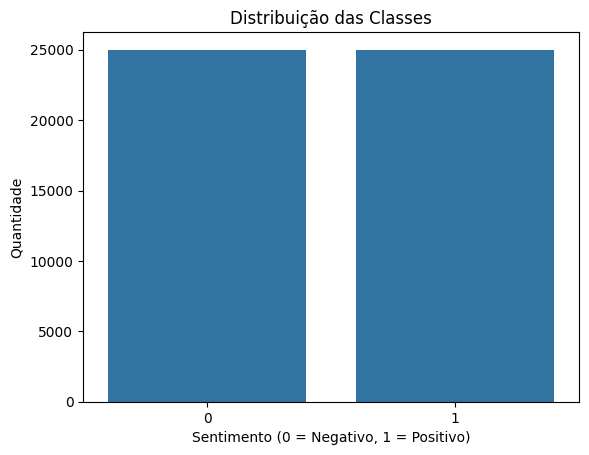

Proporção de avaliações positivas e negativas:
sentiment
1    50.0
0    50.0
Name: proportion, dtype: float64


In [8]:
# Count how many reviews belong to each class
sns.countplot(x=df["sentiment"])
plt.title("Class Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

# Check the exact proportion of each class
class_distribution = df["sentiment"].value_counts(normalize=True) * 100
print(f"Proportion of positive and negative reviews:\n{class_distribution}")


Text Length Analysis

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


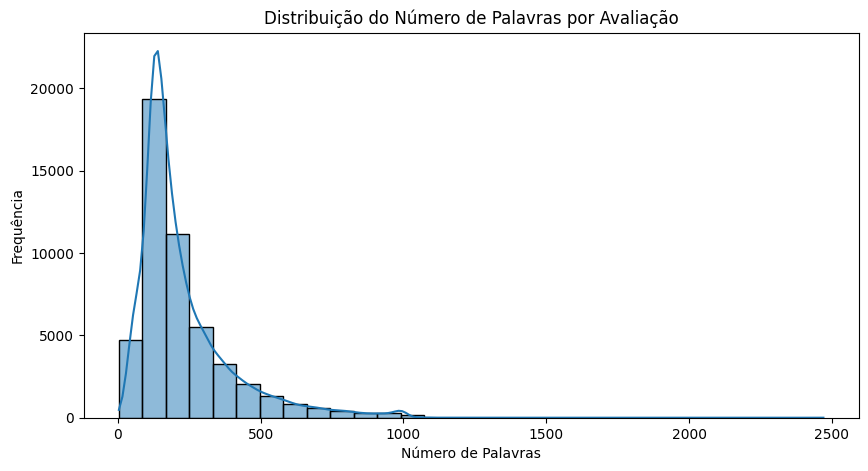

In [9]:
# Create a new column with the word count
df["word_count"] = df["review"].apply(lambda x: len(x.split()))

# Basic statistics of text length
print(df["word_count"].describe())

# Visualize the distribution of text length
plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Distribution of Word Count per Review")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


In [10]:
def analyze_dataframe(df):
    """
    Generates a detailed analysis of the given DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to be analyzed.

    Returns:
    pd.DataFrame: A DataFrame containing the analysis of the columns in the provided DataFrame.
    """
    def iqr(arr):
        arr_clean = arr[~np.isnan(arr)]  # Remove NaN values
        q1 = np.percentile(arr_clean, 25)
        q3 = np.percentile(arr_clean, 75)
        iqr_value = q3 - q1
        return iqr_value, q1, q3

    analysis = pd.DataFrame(index=df.columns)
    analysis['count'] = df.count()
    analysis['nunique'] = df.nunique()
    analysis['%unique'] = (analysis['nunique'] / len(df)) * 100
    analysis['null'] = df.isnull().sum()
    analysis['%null'] = (analysis['null'] / len(df)) * 100
    analysis['type'] = df.dtypes

    # Add descriptive statistics for numerical columns
    numeric_description = df.describe().T
    analysis = pd.concat([analysis, numeric_description], axis=1)

    return analysis

# Generate DataFrame analysis
analysis = analyze_dataframe(df)

analysis


,count,nunique,%unique,null,%null,type,count,mean,std,min,25%,50%,75%,max
review,50000,49582,99.164,0,0.0,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment,50000,2,0.004,0,0.0,int64,50000.0,0.50000,0.500005,0.0,0.0,0.5,1.0,1.0
word_count,50000,1047,2.094,0,0.0,int64,50000.0,231.15694,171.343997,4.0,126.0,173.0,280.0,2470.0


Identifying the Most Frequent Words

In [11]:
# Create a list with all words from the texts
all_words = list(itertools.chain(*[review.split() for review in df["review"]]))

# Count the frequency of each word
word_freq = Counter(all_words)

# Display the 20 most common words
print("📌 The 20 most common words in the dataset:")
word_freq.most_common(20)


📌 As 20 palavras mais comuns no dataset:


[('the', 568735),
 ('a', 306960),
 ('and', 301919),
 ('of', 283625),
 ('to', 261850),
 ('is', 203056),
 ('in', 169981),
 ('I', 132498),
 ('that', 126818),
 ('this', 113726),
 ('it', 107916),
 ('/><br', 100974),
 ('was', 92658),
 ('as', 83130),
 ('with', 82569),
 ('for', 80919),
 ('The', 67317),
 ('but', 66282),
 ('on', 61197),
 ('movie', 60762)]

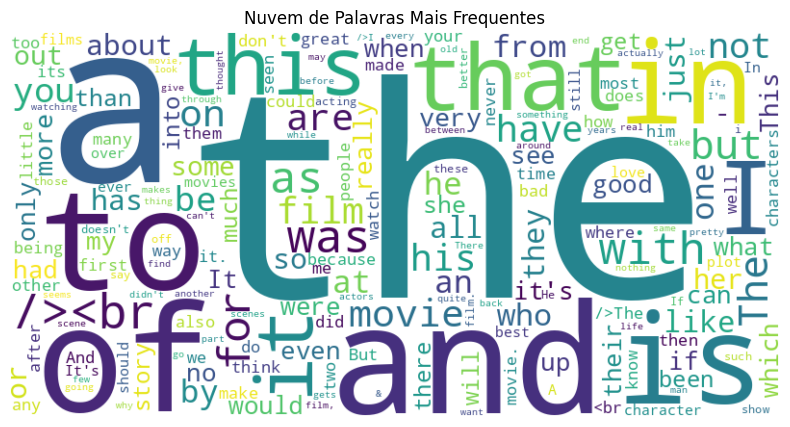

In [12]:
# Create a list with all words from the texts, removing null values
all_words = list(itertools.chain(*[str(review).split() for review in df["review"].dropna()]))

# Count the frequency of each word
word_freq = Counter(all_words)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words Word Cloud")
plt.show()


Vocabulary Comparison Between Classes

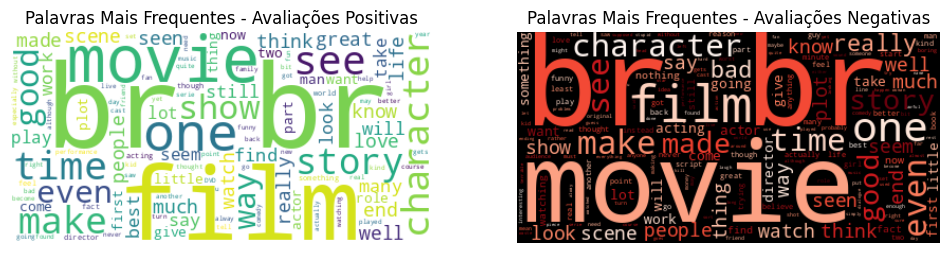

In [13]:
# Create separate lists for positive and negative reviews
positive_reviews = " ".join(df[df["sentiment"] == 1]["review"])
negative_reviews = " ".join(df[df["sentiment"] == 0]["review"])

# Create separate word clouds for each class
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
wordcloud_pos = WordCloud(width=400, height=200, background_color="white").generate(positive_reviews)
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words - Positive Reviews")

plt.subplot(1, 2, 2)
wordcloud_neg = WordCloud(width=400, height=200, background_color="black", colormap="Reds").generate(negative_reviews)
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words - Negative Reviews")

plt.show()


Stopword Identification

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


📌 Stopwords representam 45.19% do total de palavras.


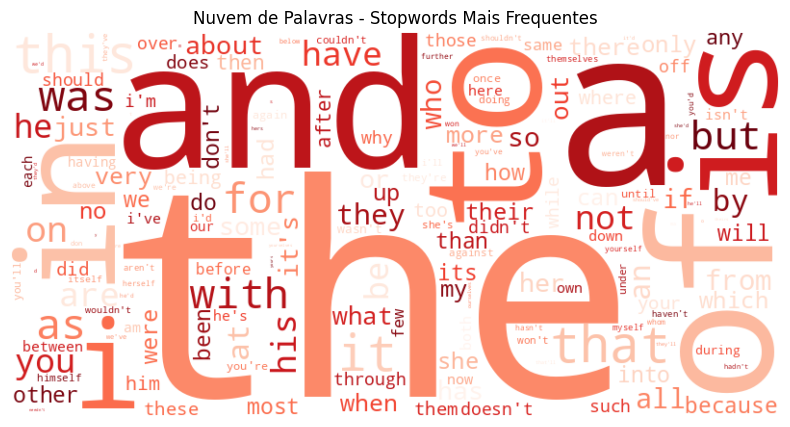

In [14]:
# Download the NLTK stopwords list
nltk.download("stopwords")

# Define English stopwords
stop_words = set(stopwords.words("english"))

# Count how many words in the dataset are stopwords
stopword_count = sum(1 for word in all_words if word.lower() in stop_words)
total_words = len(all_words)

# Display the percentage of stopwords in the dataset
print(f"📌 Stopwords represent {stopword_count/total_words:.2%} of the total words.")

# Filter only the stopwords present in the dataset
stopword_words_cloud = [word.lower() for word in all_words if word.lower() in stop_words]

# Count the frequency of stopwords
stopword_freq = Counter(stopword_words_cloud)

# Generate the word cloud for stopwords
wordcloud_stopwords = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate_from_frequencies(stopword_freq)

# Display the word cloud for stopwords
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_stopwords, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Most Frequent Stopwords")
plt.show()


Noise Detection in Text

In [16]:
# Count how many texts contain HTML
df["contains_html"] = df["review"].apply(lambda x: bool(re.search(r"<.*?>", x)))
print(f"📌 Number of texts containing HTML: {df['contains_html'].sum()}")

# Count how many texts contain numbers
df["contains_numbers"] = df["review"].apply(lambda x: any(char.isdigit() for char in x))
print(f"📌 Number of texts containing numbers: {df['contains_numbers'].sum()}")

# Count how many texts contain emojis
df["contains_emoji"] = df["review"].apply(lambda x: bool(emoji.emoji_count(x)))
print(f"📌 Number of texts containing emojis: {df['contains_emoji'].sum()}")


📌 Número de textos contendo HTML: 29202
📌 Número de textos contendo números: 28005
📌 Número de textos contendo emojis: 5


Automatic Sentiment Score Calculation

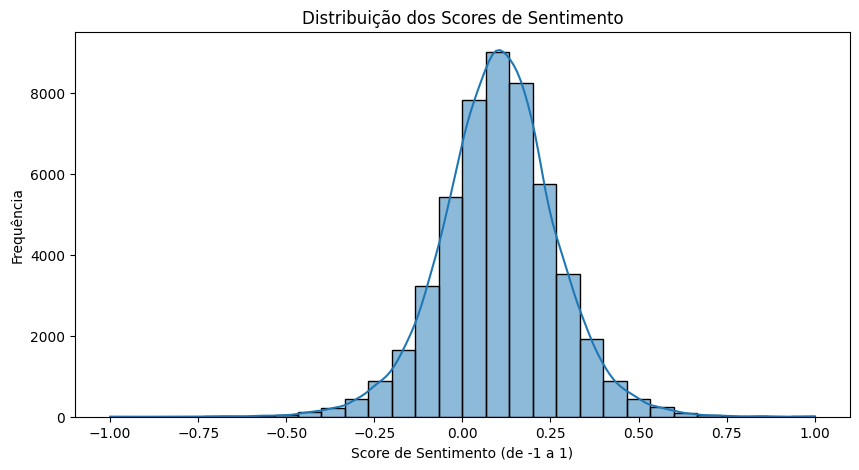

In [17]:
# Create a new column with the sentiment polarity score
df["sentiment_score"] = df["review"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Show some examples
print(df[["review", "sentiment", "sentiment_score"]].head())

# Visualize the distribution of sentiment scores
plt.figure(figsize=(10, 5))
sns.histplot(df["sentiment_score"], bins=30, kde=True)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score (from -1 to 1)")
plt.ylabel("Frequency")
plt.show()


Identifying Duplicate or Empty Texts

In [18]:
# Count duplicate texts
duplicated_texts = df.duplicated(subset=["review"]).sum()
print(f"📌 Number of duplicate texts: {duplicated_texts}")

# Count empty texts
empty_texts = df["review"].apply(lambda x: len(x.strip()) == 0).sum()
print(f"📌 Number of empty texts: {empty_texts}")


📌 Número de textos duplicados: 418
📌 Número de textos vazios: 0


📌 Número de textos duplicados: 418


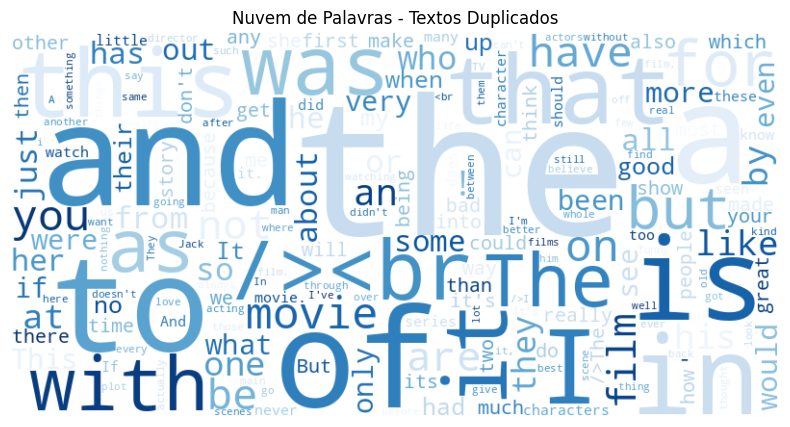

In [20]:
# Count duplicate texts
duplicated_texts_count = df.duplicated(subset=["review"]).sum()
print(f"📌 Number of duplicate texts: {duplicated_texts_count}")

# Filter duplicate texts
duplicated_reviews = df[df.duplicated(subset=["review"], keep=False)]["review"].dropna()

# Create a list with all words from duplicate texts
duplicated_words = " ".join(duplicated_reviews).split()

# Count the frequency of words in duplicate texts
duplicated_word_freq = Counter(duplicated_words)

# Generate the word cloud for duplicate texts
wordcloud_duplicated = WordCloud(width=800, height=400, background_color="white", colormap="Blues").generate_from_frequencies(duplicated_word_freq)

# Display the word cloud for duplicate texts
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_duplicated, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Duplicate Texts")
plt.show()
